# Metacatalog spectral modeling (Taylor expansion)

Post-hoc multi-point spectral fits for MHz-subband metacatalogs (15 bands, 18–82 MHz).

Subband `metacatalog.parquet` is **flux-only**: per-band `Total_flux_{band}` / `E_Total_flux_{band}` columns (no top-level `Peak_flux`/`Total_flux`, no merge-time `alpha_*`). Top-level `RA`/`DEC` come from `astrometry_band` (highest MHz present).

Each source with one or more valid `Total_flux_{band}` measurements is fit with a log-frequency **Taylor expansion** about ν₀ = **55 MHz**:

$$\ln S(\nu) = \sum_{j=0}^{n-1} a_j \left[\ln(\nu/\nu_0)\right]^j$$

Nested models with **2–4 terms** are compared. The selected model is the **simplest** whose reduced χ² is near the best fit; otherwise the lowest **BIC** wins.

**Defaults:** `flux_kind="total"` (`Total_flux_{band}`), 15 MHz subbands, output columns prefixed `spec_`.

Set `USE_SYNTHETIC = True` to run against an inline demo catalog (no `CATALOG_DIR` required).

**Run cells in order.**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    SpectralFitConfig,
    fit_metacatalog_spectra,
    gather_band_flux_measurements,
    summarize_spectral_fit,
)
from lwa_catalog.analyze.spectral import SingleSpectrumFit, evaluate_taylor_spectrum
from lwa_catalog.constants import (
    DEFAULT_QUALITY_FLAG_MASK,
    SUBBAND_BANDS_MHZ,
    SUBBAND_METACATALOG_REQUIRED_COLUMNS,
    SUBBAND_REF_FREQ_MHZ,
    band_frequency_hz,
)
from lwa_catalog.io import validate_metacatalog, write_table

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")
USE_SYNTHETIC = False  # True: inline demo catalog; False: read metacatalog_quality.parquet
QUALITY_FLAG_MASK = DEFAULT_QUALITY_FLAG_MASK  # 247; set None to keep all rows
WRITE_OUTPUT = True #: write metacatalog_spectral.parquet under CATALOG_DIR

layout = CatalogLayout(CATALOG_DIR)
config = SpectralFitConfig(
    bands=SUBBAND_BANDS_MHZ,
    ref_freq_mhz=SUBBAND_REF_FREQ_MHZ,
    flux_kind="total",
)
OUTPUT_PATH = layout.root / "metacatalog_spectral.parquet"

print("CATALOG_DIR =", layout.root.resolve())
print("USE_SYNTHETIC =", USE_SYNTHETIC)
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("WRITE_OUTPUT =", WRITE_OUTPUT)
print("OUTPUT_PATH =", OUTPUT_PATH.resolve())
print("ref_freq_mhz =", config.ref_freq_mhz)
if not USE_SYNTHETIC:
    print("metacatalog path =", resolve_metacatalog_path(layout))

CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
USE_SYNTHETIC = False
QUALITY_FLAG_MASK = 247
WRITE_OUTPUT = True
OUTPUT_PATH = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_spectral.parquet
ref_freq_mhz = 55.0
metacatalog path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_quality.parquet


## Load metacatalog

In [2]:
def _power_law_flux(nu_hz: np.ndarray, *, alpha: float, s_ref: float, nu_ref_hz: float) -> np.ndarray:
    return s_ref * (nu_hz / nu_ref_hz) ** alpha


def _build_synthetic_metacatalog(*, n_sources: int = 60) -> pd.DataFrame:
    """Demo flux-only subband catalog (matches build_subband_metacatalog layout)."""
    rng = np.random.default_rng(0)
    bands = SUBBAND_BANDS_MHZ
    nu_ref = SUBBAND_REF_FREQ_MHZ * 1e6
    rows: list[dict[str, object]] = []

    for idx in range(n_sources):
        # Coverage tiers: ~1/3 sparse (2 bands), ~1/3 medium (4), ~1/3 well-sampled (8+)
        if idx % 3 == 0:
            use_bands = bands[:2]
        elif idx % 3 == 1:
            use_bands = bands[:4]
        else:
            use_bands = bands[: max(8, 8 + idx % 7)]

        alpha_true = -0.8 + 0.3 * rng.normal()
        s_ref = 10 ** rng.uniform(-1.0, 0.5)
        nu_use = np.array([float(b.removesuffix("MHz")) * 1e6 for b in use_bands])
        flux = _power_law_flux(nu_use, alpha=alpha_true, s_ref=s_ref, nu_ref_hz=nu_ref)

        row: dict[str, object] = {
            "meta_id": idx,
            "RA": float(rng.uniform(0, 360)),
            "DEC": float(rng.uniform(-30, 45)),
            "origin_band": use_bands[-1],  # seed band (highest MHz in tier)
            "astrometry_band": use_bands[-1],
            "bands_present": ",".join(use_bands),
        }
        for band, value in zip(use_bands, flux, strict=True):
            row[f"Total_flux_{band}"] = float(value)
            row[f"E_Total_flux_{band}"] = 0.05 * float(value)

        rows.append(row)

    return pd.DataFrame(rows)


if USE_SYNTHETIC or not resolve_metacatalog_path(layout).is_file():
    if not USE_SYNTHETIC:
        print(f"No metacatalog at {resolve_metacatalog_path(layout)}; using synthetic demo catalog.")
    metacatalog = _build_synthetic_metacatalog()
else:
    metacatalog = read_metacatalog(
        layout,
        validate=False,
        quality_mask=QUALITY_FLAG_MASK,
    )
    validate_metacatalog(metacatalog, required=SUBBAND_METACATALOG_REQUIRED_COLUMNS)

n_total_flux = sum(c.startswith("Total_flux_") for c in metacatalog.columns)
print(f"metacatalog rows: {len(metacatalog)}")
print(f"Total_flux_{{band}} columns: {n_total_flux}")
print(f"Top-level Peak_flux present: {'Peak_flux' in metacatalog.columns}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")

metacatalog rows: 73026
Total_flux_{band} columns: 15
Top-level Peak_flux present: False
quality_flag present: True


## Fit Taylor spectra

In [3]:
result = fit_metacatalog_spectra(metacatalog, config=config)
fitted = result.metacatalog
print(summarize_spectral_fit(result))

Sources:                       73026
Fitted (>=1 flux):             72064
Median BIC:                   -12.579
Median flux channels:         10.0
Model terms selected:
  2-term:  35989
  3-term:  18194
  4-term:  17881


## Diagnostics

Selected model terms (value_counts):


spec_model_n_terms
0      962
2    35989
3    18194
4    17881
Name: count, dtype: int64

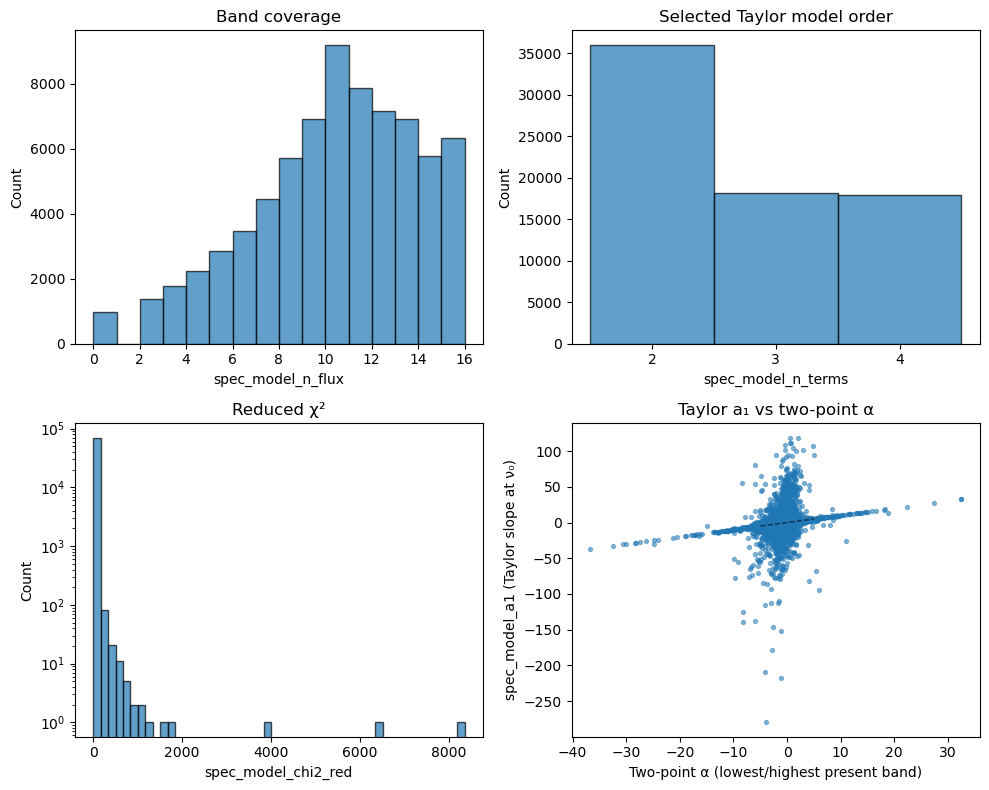

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

prefix = config.column_prefix
n_terms_col = f"{prefix}model_n_terms"
n_flux_col = f"{prefix}model_n_flux"
chi2_col = f"{prefix}model_chi2_red"
a1_col = f"{prefix}model_a1"

print("Selected model terms (value_counts):")
display(fitted[n_terms_col].value_counts().sort_index())


def _two_point_alpha_from_present_bands(row: pd.Series) -> float:
    """Spectral index from lowest/highest valid per-band flux measurements."""
    nu_hz, flux_jy, _ = gather_band_flux_measurements(
        row,
        bands=config.bands,
        flux_kind=config.flux_kind,
    )
    if nu_hz.size < 2:
        return np.nan
    s_lo, s_hi = float(flux_jy[0]), float(flux_jy[-1])
    if s_lo <= 0.0 or s_hi <= 0.0:
        return np.nan
    return float(np.log(s_hi / s_lo) / np.log(nu_hz[-1] / nu_hz[0]))


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

n_flux = pd.to_numeric(fitted[n_flux_col], errors="coerce")
n_flux_max = int(n_flux.max()) if n_flux.notna().any() else 0
axes[0, 0].hist(
    n_flux.dropna(),
    bins=range(0, n_flux_max + 2),
    edgecolor="k",
    alpha=0.7,
)
axes[0, 0].set_xlabel(n_flux_col)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Band coverage")

n_terms = pd.to_numeric(fitted[n_terms_col], errors="coerce")
axes[0, 1].hist(
    n_terms.dropna(),
    bins=[1.5, 2.5, 3.5, 4.5],
    edgecolor="k",
    alpha=0.7,
)
axes[0, 1].set_xticks([2, 3, 4])
axes[0, 1].set_xlabel(n_terms_col)
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Selected Taylor model order")

chi2 = pd.to_numeric(fitted[chi2_col], errors="coerce")
chi2_finite = chi2.dropna()
if not chi2_finite.empty:
    axes[1, 0].hist(chi2_finite, bins=50, edgecolor="k", alpha=0.7, log='x')
axes[1, 0].set_xlabel(chi2_col)
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Reduced χ²")

alpha = fitted.apply(_two_point_alpha_from_present_bands, axis=1)
a1 = pd.to_numeric(fitted[a1_col], errors="coerce")
ok = np.isfinite(alpha) & np.isfinite(a1)
if ok.any():
    axes[1, 1].scatter(alpha.loc[ok], a1.loc[ok], s=8, alpha=0.5)
    lim = (
#        min(alpha.loc[ok].min(), a1.loc[ok].min()),
#        max(alpha.loc[ok].max(), a1.loc[ok].max()),
        -5, 5
    )
    axes[1, 1].plot(lim, lim, "k--", lw=1, alpha=0.6)
    axes[1, 1].set_xlabel("Two-point α (lowest/highest present band)")
    axes[1, 1].set_ylabel(f"{a1_col} (Taylor slope at ν₀)")
    axes[1, 1].set_title("Taylor a₁ vs two-point α")
else:
    axes[1, 1].text(
        0.5,
        0.5,
        "No α comparison\n(need ≥2 valid flux bands)",
        ha="center",
        va="center",
        transform=axes[1, 1].transAxes,
    )
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## Interactive SED explorer

Browse fitted sources in the table below. **Click a row** (or enter `meta_id`) to plot flux versus frequency: data points with errors and the selected Taylor model.

Adjust `TABLE_MIN_N_FLUX` / `TABLE_MAX_ROWS` in the next cell if the table is slow on large catalogs.

Interactive table: 5,000 rows (n_flux >= 2, max 5,000)


Column
    [0] Markdown(str)
    [1] Row
        [0] IntInput(label='meta_id', name='meta_id', start=0, value=6, width=140)
        [1] Button(button_type='primary', color='primary', label='Plot', name='Plot', width=80)
    [2] Tabulator(disabled=True, height=420, page_size=20, pagination='local', show_index=False, sizing_mode='stretch_width', value=      meta_id          RA ...)
    [3] Matplotlib(Figure, tight=True)
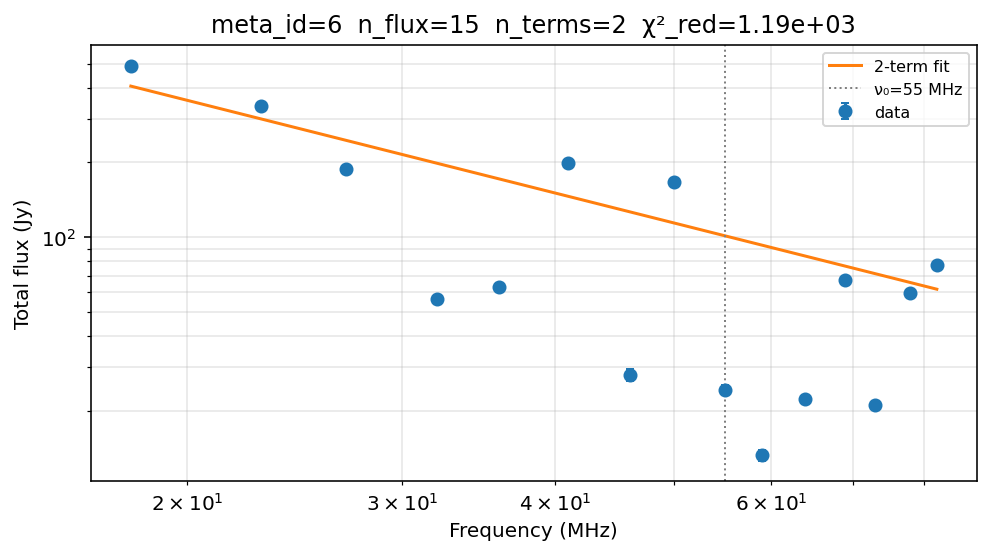

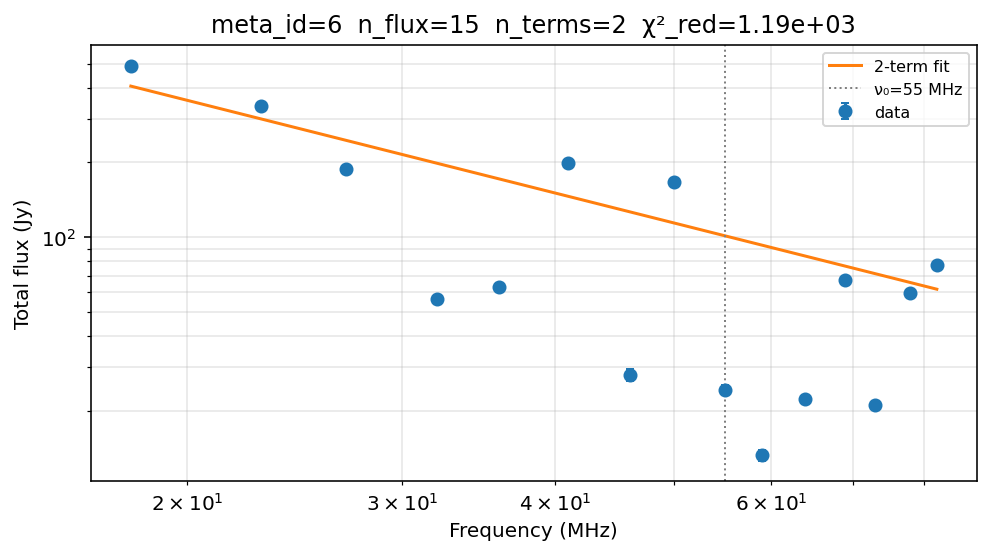

In [5]:
import panel as pn

pn.extension("tabulator", throttled=True)

TABLE_MIN_N_FLUX = 2  # only rows with at least this many valid flux channels
TABLE_MAX_ROWS = 5000  # cap rows sent to the browser for responsiveness

SPEC_TABLE_COLUMNS = [
    "meta_id",
    "RA",
    "DEC",
    "origin_band",
    "astrometry_band",
    "bands_present",
    f"{prefix}model_n_flux",
    f"{prefix}model_n_terms",
    f"{prefix}model_a0",
    f"{prefix}model_a1",
    f"{prefix}model_a2",
    f"{prefix}model_a3",
    f"{prefix}model_bic",
    f"{prefix}model_chi2_red",
]


def _row_to_fit(row: pd.Series) -> SingleSpectrumFit:
    return SingleSpectrumFit(
        n_terms=int(row[f"{prefix}model_n_terms"]),
        bic=float(row[f"{prefix}model_bic"]),
        chi2_red=float(row[f"{prefix}model_chi2_red"]),
        n_flux=int(row[f"{prefix}model_n_flux"]),
        coeffs=(
            float(row[f"{prefix}model_a0"]),
            float(row[f"{prefix}model_a1"]),
            float(row[f"{prefix}model_a2"]),
            float(row[f"{prefix}model_a3"]),
        ),
        nu0_mhz=float(row[f"{prefix}model_nu0_mhz"]),
    )


def plot_sed_for_meta_id(meta_id: int) -> plt.Figure:
    """Plot Total_flux vs frequency for one metacatalog source."""
    matches = fitted.loc[fitted["meta_id"] == meta_id]
    fig, ax = plt.subplots(figsize=(7, 4))
    if matches.empty:
        ax.text(
            0.5,
            0.5,
            f"meta_id {meta_id} not found",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        return fig

    row = matches.iloc[0]
    nu_hz, flux_jy, err_jy = gather_band_flux_measurements(
        row,
        bands=config.bands,
        flux_kind=config.flux_kind,
    )
    fit = _row_to_fit(row)

    if nu_hz.size == 0:
        ax.text(
            0.5,
            0.5,
            f"meta_id {meta_id}: no valid flux measurements",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        return fig

    nu_mhz = nu_hz / 1e6
    nu_curve = np.geomspace(nu_mhz.min(), nu_mhz.max(), 100)
    flux_curve = evaluate_taylor_spectrum(nu_curve * 1e6, fit)

    ax.errorbar(nu_mhz, flux_jy, yerr=err_jy, fmt="o", capsize=2, label="data")
    ax.plot(nu_curve, flux_curve, "-", label=f"{fit.n_terms}-term fit")
    ax.axvline(
        config.ref_freq_mhz,
        color="0.5",
        ls=":",
        lw=1,
        label=f"ν₀={config.ref_freq_mhz:g} MHz",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Total flux (Jy)")
    if np.isfinite(fit.chi2_red):
        title = (
            f"meta_id={meta_id}  n_flux={fit.n_flux}  n_terms={fit.n_terms}  "
            f"χ²_red={fit.chi2_red:.3g}"
        )
    else:
        title = f"meta_id={meta_id}  n_flux={fit.n_flux}  n_terms={fit.n_terms}"
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    return fig


sed_table = (
    fitted.loc[fitted[n_flux_col] >= TABLE_MIN_N_FLUX, SPEC_TABLE_COLUMNS]
    .sort_values([n_flux_col, "meta_id"], ascending=[False, True])
    .head(TABLE_MAX_ROWS)
    .reset_index(drop=True)
)
default_meta_id = int(sed_table.iloc[0]["meta_id"]) if not sed_table.empty else 0

meta_id_input = pn.widgets.IntInput(
    name="meta_id",
    value=default_meta_id,
    start=0,
    width=140,
)
plot_button = pn.widgets.Button(name="Plot", button_type="primary", width=80)
plot_pane = pn.pane.Matplotlib(plot_sed_for_meta_id(default_meta_id), tight=True)

source_table = pn.widgets.Tabulator(
    sed_table,
    pagination="local",
    page_size=20,
    sizing_mode="stretch_width",
    height=420,
    selectable=1,
    show_index=False,
    disabled=True,
)

def _plot_meta_id(meta_id: int) -> None:
    plot_pane.object = plot_sed_for_meta_id(int(meta_id))


def _on_plot_button(event) -> None:
    _plot_meta_id(meta_id_input.value)


def _on_table_select(event) -> None:
    if not source_table.selection:
        return
    row_idx = source_table.selection[0]
    meta_id = int(source_table.value.iloc[row_idx]["meta_id"])
    meta_id_input.value = meta_id
    _plot_meta_id(meta_id)


plot_button.on_click(_on_plot_button)
source_table.param.watch(_on_table_select, "selection")

print(
    f"Interactive table: {len(sed_table):,} rows "
    f"(n_flux >= {TABLE_MIN_N_FLUX}, max {TABLE_MAX_ROWS:,})"
)

pn.Column(
    pn.pane.Markdown("Click a table row or set `meta_id` to update the SED plot."),
    pn.Row(meta_id_input, plot_button),
    source_table,
    plot_pane,
)

## Optional write

Writes `metacatalog_spectral.parquet` (original columns + `spec_*` fit columns). Set `WRITE_OUTPUT = True` in the config cell.

In [6]:
if WRITE_OUTPUT:
    write_table(result.metacatalog, OUTPUT_PATH, include_extras=True)
    print(f"Wrote {OUTPUT_PATH}")
else:
    print("Skipping write (WRITE_OUTPUT=False)")

Wrote /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_spectral.parquet
